<a href="https://colab.research.google.com/github/rkaykothari-maker/ores5160-2026/blob/main/Copy_of_EDA_CDC_Chronic__Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("cdc_chronic_disease.csv")
df.head()

/tmp/ipykernel_244/2702143588.py:1: DtypeWarning: Columns (10,11,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cdc_chronic_disease.csv")


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(309215, 34)

In [ ]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType',
       'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol',
       'DataValueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit',
       'StratificationCategory1', 'Stratification1', 'StratificationCategory2',
       'Stratification2', 'StratificationCategory3', 'Stratification3',
       'Geolocation', 'LocationID', 'TopicID', 'QuestionID', 'ResponseID',
       'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1',
       'StratificationCategoryID2', 'StratificationID2',
       'StratificationCategoryID3', 'StratificationID3'],
      dtype='object')

In [ ]:
df['DataValue'] = pd.to_numeric(df['DataValue'], errors='coerce')

In [ ]:
df_clean = df.dropna(subset=['DataValue'])
df_clean.shape

(201099, 34)

In [ ]:
df_clean['Topic'].value_counts().head(10)

,count
Topic,
Cardiovascular Disease,20359
"Nutrition, Physical Activity, and Weight Status",19618
Health Status,19157
Alcohol,16224
Chronic Obstructive Pulmonary Disease,15844
Cancer,15006
Social Determinants of Health,12307
Immunization,12242
Arthritis,11960


In [ ]:
cardio = df_clean[df_clean['Topic'] == 'Cardiovascular Disease']
cardio.shape

(20359, 34)

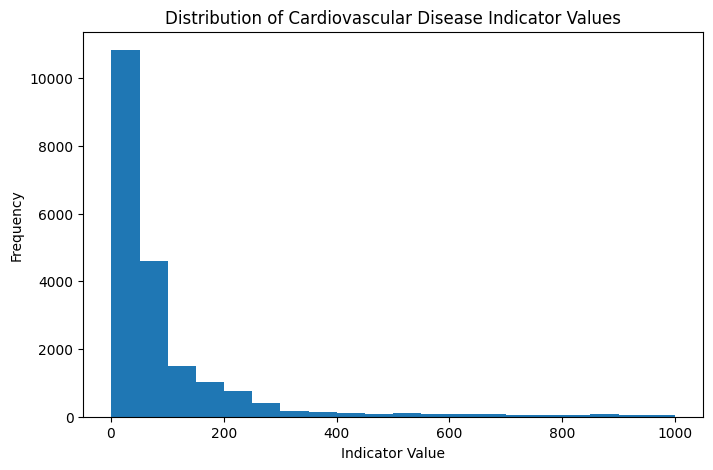

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(cardio['DataValue'], bins=20)
plt.title("Distribution of Cardiovascular Disease Indicator Values")
plt.xlabel("Indicator Value")
plt.ylabel("Frequency")
plt.show()

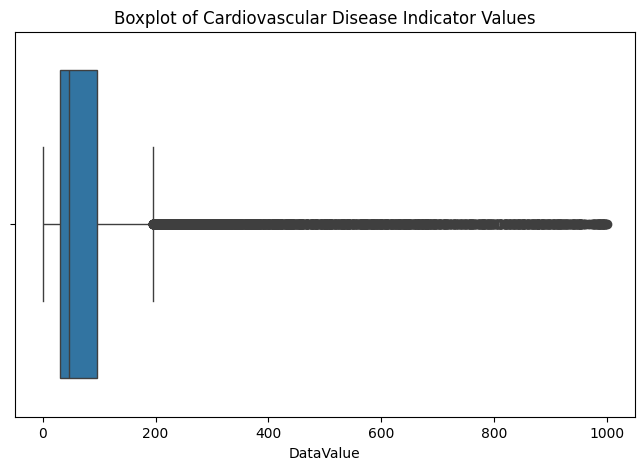

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=cardio['DataValue'])
plt.title("Boxplot of Cardiovascular Disease Indicator Values")
plt.show()

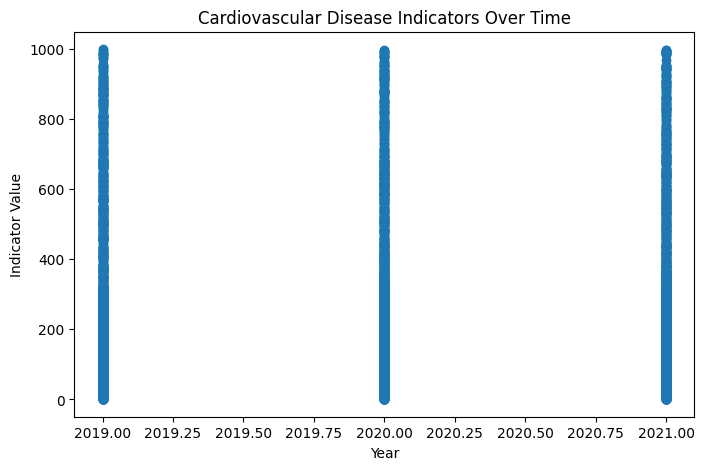

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(cardio['YearStart'], cardio['DataValue'])
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title("Cardiovascular Disease Indicators Over Time")
plt.show()